# Email Experiment Analysis: Improving User Funding Through Email Engagement

## Introduction

For a fintech platform, converting approved but unfunded users into funded and active users is an important part of the customer journey. Email campaigns can help encourage these users to take action, but their effectiveness may depend on the message, user segment, delivery frequency, and timing.

This project analyzes a multi-arm email experiment designed to evaluate how email communication affects user engagement and account funding. The experiment includes approximately 480,000 users across 12 behavioral segments. Users in the treatment sample received 10 different email templates under either a daily or twice-weekly delivery schedule, while comparable control groups did not receive experimental emails.

The analysis focuses on five questions:

1. Which email generates the strongest open rate, and which user characteristics are associated with higher engagement?
2. What are the account-linking and funding rates among treatment groups?
3. Does receiving experimental emails significantly increase funding rates relative to control groups?
4. How does email engagement change over time, and what does this suggest about delivery strategy?
5. What does the conversion funnel from email engagement to account linking and funding look like?

The goal is to translate the experiment results into practical recommendations for email targeting and delivery strategy.

## 0. Setup and Data Preparation

This section loads the experiment datasets and performs the minimal preparation required for the analysis. The data includes user segmentation, randomized email delivery orders, email interaction events, user-level outcomes, and aggregated control-group outcomes.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from statsmodels.stats.proportion import proportions_ztest

%matplotlib inline

pd.options.display.max_columns = None

### 0.1 Load the Data

The experiment uses five datasets:

- **Segment groups:** definitions of the 12 behavioral user segments.
- **Experiment users:** user-level treatment assignments and randomized email delivery orders.
- **Email events:** event-level records of email delivery and engagement.
- **User events:** user-level email engagement and account outcomes.
- **Control groups:** aggregated linking and funding outcomes for comparable users who did not receive experimental emails.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
DATA_PATH = '/content/drive/MyDrive/Email_project/'

In [19]:
# Email template list
# Email IDs correspond to the index of each template in this list.

PO_number_list = [
    'ml_funding_enables_investing',
    'ml_investing_starts_here',
    'ml_explore_the_app_investing',
    'ml_funding_faq',
    'ml_user_clustering_emails_fracs',
    'ml_funding_is_safe',
    'ml_picking_an_investment',
    'ml_investing_101',
    'ml_diversified_portfolio',
    'ml_explore_the_app_list'
]

PO_number_list

['ml_funding_enables_investing',
 'ml_investing_starts_here',
 'ml_explore_the_app_investing',
 'ml_funding_faq',
 'ml_user_clustering_emails_fracs',
 'ml_funding_is_safe',
 'ml_picking_an_investment',
 'ml_investing_101',
 'ml_diversified_portfolio',
 'ml_explore_the_app_list']

In [20]:
# Load experiment datasets

segment_group_init_df = pd.read_csv(
    DATA_PATH + 'sample_segment_groups.csv'
)

sample_exp_df = pd.read_csv(
    DATA_PATH + 'sample_uuid_email_order.csv'
)

email_event_summary_df = pd.read_csv(
    DATA_PATH + 'email_events.csv'
)

user_event_df = pd.read_csv(
    DATA_PATH + 'user_events.csv'
)

fund_control_df = pd.read_csv(
    DATA_PATH + 'control_groups_rate.csv'
)

# Remove exported index column if present
if 'Unnamed: 0' in segment_group_init_df.columns:
    segment_group_init_df = segment_group_init_df.drop(columns='Unnamed: 0')

In [21]:
# Dataset overview

dataset_summary = pd.DataFrame({
    'Dataset': [
        'Segment Groups',
        'Experiment Users',
        'Email Events',
        'User Events',
        'Control Groups'
    ],
    'Rows': [
        len(segment_group_init_df),
        len(sample_exp_df),
        len(email_event_summary_df),
        len(user_event_df),
        len(fund_control_df)
    ],
    'Columns': [
        segment_group_init_df.shape[1],
        sample_exp_df.shape[1],
        email_event_summary_df.shape[1],
        user_event_df.shape[1],
        fund_control_df.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Segment Groups,12,7
1,Experiment Users,480000,13
2,Email Events,9553330,6
3,User Events,480000,22
4,Control Groups,12,6


The experiment contains 480,000 treatment users with corresponding user-level outcome records. Email interactions are stored separately at the event level, resulting in approximately 9.6 million email-event records. Control-group outcomes are provided as aggregated metrics for the corresponding user segments.

### 0.2 Data Preparation

Date fields were converted to datetime format for subsequent time-based analysis. Missing outcome values were preserved because they represent meaningful user states, such as users who had not linked or funded their accounts.

One duplicated user record was identified in both user-level datasets. The duplicate outcome record was identical, while the experiment assignment records placed the user in the same treatment group with different randomized email orders. One record was retained to maintain a single observation per user.

In [31]:
# Convert date columns to datetime format

user_event_df['approved_at'] = pd.to_datetime(
    user_event_df['approved_at'],
    errors='coerce'
)

user_event_df['first_funded_at'] = pd.to_datetime(
    user_event_df['first_funded_at'],
    errors='coerce'
)

user_event_df['first_linked_bank_account_at'] = pd.to_datetime(
    user_event_df['first_linked_bank_account_at'],
    errors='coerce'
)

email_event_summary_df['stitch_email_events.dt_date'] = pd.to_datetime(
    email_event_summary_df['stitch_email_events.dt_date'],
    errors='coerce'
)

In [32]:
# Remove duplicate user records

# user_events contains one exact duplicate record
user_event_df = user_event_df.drop_duplicates()

# One user appears twice in the experiment assignment data with the same
# treatment group but different randomized email orders.
# Keep one record to maintain one row per user for user-level analysis.
sample_exp_df = sample_exp_df.drop_duplicates(
    subset='user_uuid',
    keep='first'
)

print(f"Experiment users after deduplication: {len(sample_exp_df):,}")
print(f"User outcome records after deduplication: {len(user_event_df):,}")

print("Duplicate experiment users:",
      sample_exp_df['user_uuid'].duplicated().sum())

print("Duplicate outcome users:",
      user_event_df['user_uuid'].duplicated().sum())

Experiment users after deduplication: 479,999
User outcome records after deduplication: 479,999
Duplicate experiment users: 0
Duplicate outcome users: 0


### 0.3 Create the User-Level Analysis Dataset

The experiment assignment data is merged with user-level engagement and account outcomes using `user_uuid`. This creates one analysis dataset containing each user's treatment group, randomized email order, email engagement status, and account outcomes.

A one-to-one merge is used because each user should appear only once in both datasets after deduplication.

In [33]:
# Merge experiment assignments with user-level outcomes

analysis_df = sample_exp_df.merge(
    user_event_df.drop(columns='group_name'),
    on='user_uuid',
    how='left',
    validate='one_to_one'
)

print(f"Analysis dataset: {analysis_df.shape[0]:,} users")
print(f"Number of columns: {analysis_df.shape[1]}")
print(f"Users with missing outcome records: {analysis_df['approved_at'].isna().sum():,}")

Analysis dataset: 479,999 users
Number of columns: 33
Users with missing outcome records: 0


The final user-level analysis dataset contains 479,999 unique experiment users, and all users were successfully matched to their corresponding outcome records.

## 1. Email Open Rate Analysis

## 1. Email Open Rate Analysis

Email open rate provides a direct measure of user engagement with the experiment emails. This section compares engagement across the 10 email templates and examines whether open behavior differs across user segments.

### 1.1 Which Email Has the Highest Open Rate?

To compare the 10 email templates, the user-level email status columns are used to determine whether each email was delivered and whether the user opened it. Open rate is calculated as the proportion of delivered emails that were opened.

In [34]:
# Email status columns

email_cols = PO_number_list

# Combine the 10 email columns to inspect possible status values
email_status_counts = (
    user_event_df[email_cols]
    .stack()
    .value_counts()
)

email_status_counts

,count
delivered,3412880
open,774163
unsubscribe,1076
spamreport,227


In [35]:
# Calculate open rate for each email template

open_rate_results = []

for email in email_cols:
    status_counts = user_event_df[email].value_counts()

    opened = status_counts.get('open', 0)
    delivered_only = status_counts.get('delivered', 0)

    total_delivered = opened + delivered_only
    open_rate = opened / total_delivered if total_delivered > 0 else np.nan

    open_rate_results.append({
        'email': email,
        'opened': opened,
        'delivered': total_delivered,
        'open_rate': open_rate
    })

open_rate_df = pd.DataFrame(open_rate_results)

open_rate_df = open_rate_df.sort_values(
    'open_rate',
    ascending=False
).reset_index(drop=True)

open_rate_df

,email,opened,delivered,open_rate
0,ml_funding_faq,108794,418679,0.259851
1,ml_user_clustering_emails_fracs,76385,418258,0.182627
2,ml_picking_an_investment,74827,418688,0.178718
3,ml_explore_the_app_list,74365,418147,0.177844
4,ml_funding_is_safe,74214,419144,0.177061
5,ml_investing_101,73746,418325,0.176289
6,ml_investing_starts_here,73455,418513,0.175514
7,ml_funding_enables_investing,73024,419578,0.174042
8,ml_explore_the_app_investing,72784,418771,0.173804
9,ml_diversified_portfolio,72569,418940,0.173221


In [36]:
# Create readable email labels for visualization

open_rate_df['email_label'] = (
    open_rate_df['email']
    .str.replace('ml_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
)

display_df = open_rate_df[
    ['email_label', 'opened', 'delivered', 'open_rate']
].copy()

display_df['open_rate'] = (
    display_df['open_rate'] * 100
).round(2)

display_df.columns = [
    'Email',
    'Opened',
    'Delivered',
    'Open Rate (%)'
]

display_df

,Email,Opened,Delivered,Open Rate (%)
0,Funding Faq,108794,418679,25.99
1,User Clustering Emails Fracs,76385,418258,18.26
2,Picking An Investment,74827,418688,17.87
3,Explore The App List,74365,418147,17.78
4,Funding Is Safe,74214,419144,17.71
5,Investing 101,73746,418325,17.63
6,Investing Starts Here,73455,418513,17.55
7,Funding Enables Investing,73024,419578,17.40
8,Explore The App Investing,72784,418771,17.38
9,Diversified Portfolio,72569,418940,17.32


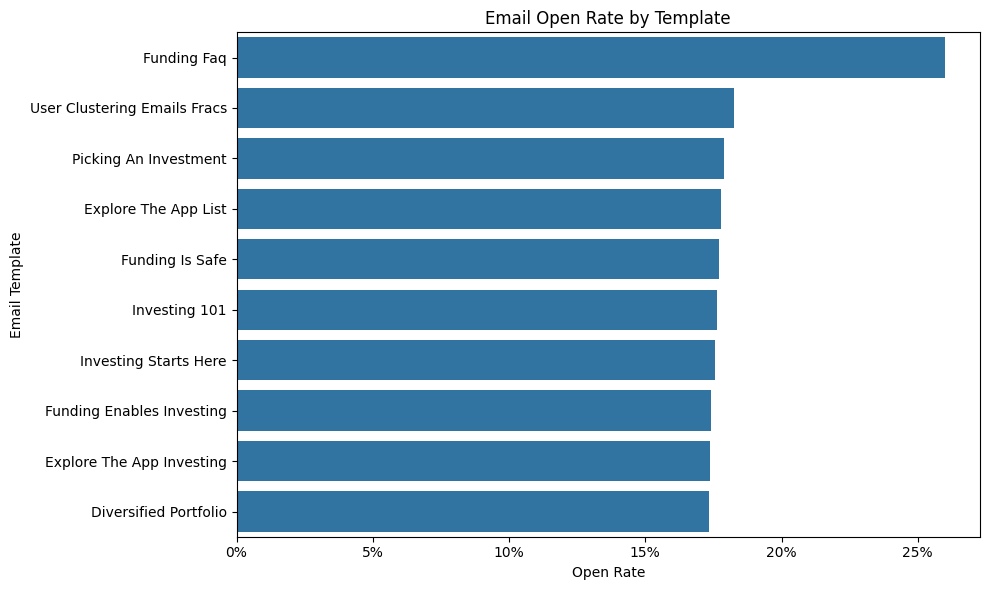

In [37]:
# Visualize open rate by email template

plt.figure(figsize=(10, 6))

sns.barplot(
    data=open_rate_df,
    x='open_rate',
    y='email_label'
)

plt.xlabel('Open Rate')
plt.ylabel('Email Template')
plt.title('Email Open Rate by Template')

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

plt.tight_layout()
plt.show()

In [38]:
# Identify the highest-performing email

best_email = open_rate_df.iloc[0]

print(
    f"Highest open rate: {best_email['email_label']} "
    f"({best_email['open_rate']:.2%})"
)

Highest open rate: Funding Faq (25.99%)


#### Key Finding

**Funding FAQ** achieved the highest open rate at **25.99%**, substantially higher than all other email templates. The second-highest template, **User Clustering Emails Fracs**, had an open rate of **18.26%**, while the remaining templates were tightly clustered between approximately **17.3% and 17.9%**.

This suggests that the Funding FAQ email was particularly effective at capturing users' attention. Based on open rate alone, it is the strongest-performing email template in the experiment and may provide useful direction for future email messaging.

### 1.2 Which User Segment Factors Are Associated with Open Rate?

The experiment segments users based on several behavioral characteristics, including recent approval, existing bank-account linkage, recent activity, and recent trading activity.

To understand which characteristics are associated with email engagement, this section compares the overall email open rate between users with and without each segment factor. These comparisons are descriptive and show associations rather than causal effects.

In [39]:
# Recover the base segment name by removing delivery-frequency suffix

analysis_df['base_group_name'] = (
    analysis_df['group_name']
    .str.replace(r'_[DW]$', '', regex=True)
)

segment_flags = segment_group_init_df[
    [
        'group_name',
        'approved_within6M_flag',
        'link_flag',
        'recent_activity_flag(20days)',
        '5day_trade_flag'
    ]
].copy()

segment_flags = segment_flags.rename(
    columns={'group_name': 'base_group_name'}
)

analysis_df = analysis_df.merge(
    segment_flags,
    on='base_group_name',
    how='left',
    validate='many_to_one'
)

analysis_df[
    [
        'group_name',
        'base_group_name',
        'approved_within6M_flag',
        'link_flag',
        'recent_activity_flag(20days)',
        '5day_trade_flag'
    ]
].head()

,group_name,base_group_name,approved_within6M_flag,link_flag,recent_activity_flag(20days),5day_trade_flag
0,ML_unfund_exp_control_D,ML_unfund_exp_control,False,False,False,False
1,ML_unfund_exp_control_D,ML_unfund_exp_control,False,False,False,False
2,ML_unfund_exp_control_D,ML_unfund_exp_control,False,False,False,False
3,ML_unfund_exp_control_D,ML_unfund_exp_control,False,False,False,False
4,ML_unfund_exp_control_D,ML_unfund_exp_control,False,False,False,False


In [40]:
# Check that all experiment users were matched to segment characteristics

print(
    "Users with missing segment information:",
    analysis_df['approved_within6M_flag'].isna().sum()
)

Users with missing segment information: 0


In [41]:
# Calculate each user's number of opened and delivered emails

analysis_df['num_opened'] = (
    analysis_df[email_cols]
    .eq('open')
    .sum(axis=1)
)

analysis_df['num_delivered'] = (
    analysis_df[email_cols]
    .isin(['open', 'delivered'])
    .sum(axis=1)
)

analysis_df['user_open_rate'] = (
    analysis_df['num_opened']
    / analysis_df['num_delivered']
)

analysis_df[
    ['num_opened', 'num_delivered', 'user_open_rate']
].describe()

,num_opened,num_delivered,user_open_rate
count,479999.000000,479999.000000,456543.000000
mean,1.612843,8.723024,0.190823
std,2.388634,2.455622,0.269130
min,0.000000,0.000000,0.000000
25%,0.000000,9.000000,0.000000
50%,1.000000,9.000000,0.100000
75%,2.000000,10.000000,0.300000
max,10.000000,10.000000,1.000000


#### Open Rate by User Characteristic

For each segmentation factor, users are divided into two groups based on whether the characteristic was present at the beginning of the experiment. Open rates are then compared across the two groups.

In [42]:
segment_factors = {
    'approved_within6M_flag': 'Approved Within 6 Months',
    'link_flag': 'Already Linked',
    'recent_activity_flag(20days)': 'Active Within 20 Days',
    '5day_trade_flag': 'Traded Within 5 Days'
}

factor_results = []

for factor, label in segment_factors.items():

    for flag in [False, True]:

        subset = analysis_df[analysis_df[factor] == flag]

        opened = subset['num_opened'].sum()
        delivered = subset['num_delivered'].sum()

        open_rate = opened / delivered

        factor_results.append({
            'factor': label,
            'flag': flag,
            'users': len(subset),
            'opened': opened,
            'delivered': delivered,
            'open_rate': open_rate
        })

factor_open_rate_df = pd.DataFrame(factor_results)

factor_open_rate_df

,factor,flag,users,opened,delivered,open_rate
0,Approved Within 6 Months,False,239999,364684,2055450,0.177423
1,Approved Within 6 Months,True,240000,409479,2131593,0.192100
2,Already Linked,False,240000,379664,2110117,0.179926
3,Already Linked,True,239999,394499,2076926,0.189944
4,Active Within 20 Days,False,159999,215570,1309209,0.164657
5,Active Within 20 Days,True,320000,558593,2877834,0.194102
6,Traded Within 5 Days,False,319999,496163,2737497,0.181247
7,Traded Within 5 Days,True,160000,278000,1449546,0.191784


In [43]:
factor_comparison_df = (
    factor_open_rate_df
    .pivot(
        index='factor',
        columns='flag',
        values='open_rate'
    )
    .reset_index()
)

factor_comparison_df.columns = [
    'User Characteristic',
    'Without Characteristic',
    'With Characteristic'
]

factor_comparison_df['Difference (pp)'] = (
    (
        factor_comparison_df['With Characteristic']
        - factor_comparison_df['Without Characteristic']
    ) * 100
)

factor_comparison_df['Without Characteristic'] = (
    factor_comparison_df['Without Characteristic'] * 100
).round(2)

factor_comparison_df['With Characteristic'] = (
    factor_comparison_df['With Characteristic'] * 100
).round(2)

factor_comparison_df['Difference (pp)'] = (
    factor_comparison_df['Difference (pp)'].round(2)
)

factor_comparison_df

,User Characteristic,Without Characteristic,With Characteristic,Difference (pp)
0,Active Within 20 Days,16.47,19.41,2.94
1,Already Linked,17.99,18.99,1.00
2,Approved Within 6 Months,17.74,19.21,1.47
3,Traded Within 5 Days,18.12,19.18,1.05


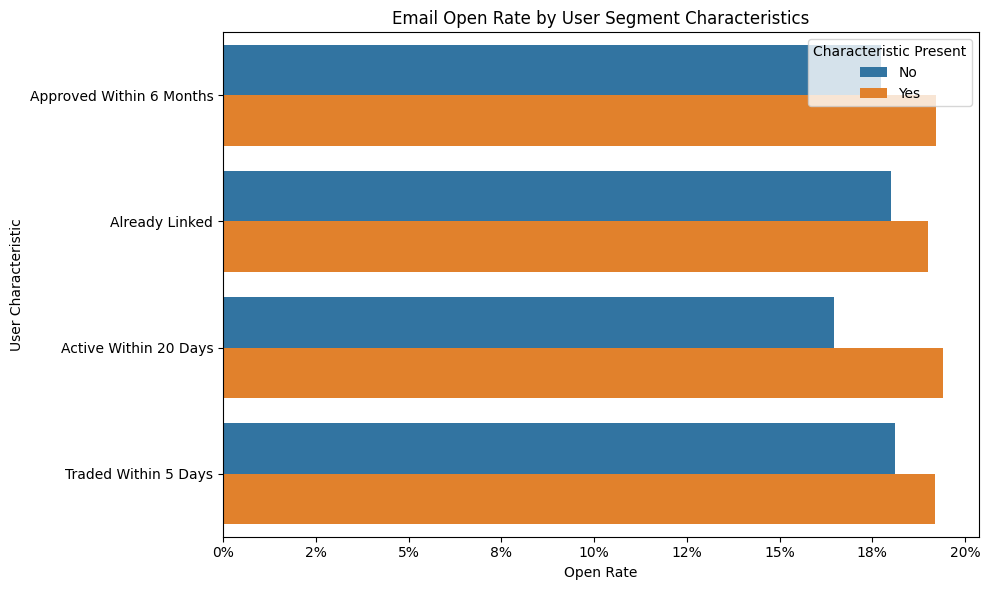

In [44]:
# Visualize open-rate differences by user characteristic

plot_df = factor_open_rate_df.copy()

plot_df['Status'] = plot_df['flag'].map({
    False: 'No',
    True: 'Yes'
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='open_rate',
    y='factor',
    hue='Status'
)

plt.xlabel('Open Rate')
plt.ylabel('User Characteristic')
plt.title('Email Open Rate by User Segment Characteristics')

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

plt.legend(title='Characteristic Present')
plt.tight_layout()
plt.show()

#### Key Finding

Recent user activity shows the strongest association with email engagement. Users who were active within the previous 20 days had an open rate of **19.41%**, compared with **16.47%** among less recently active users, a difference of **2.94 percentage points**.

The other segment characteristics were also associated with moderately higher open rates. Users approved within the previous six months had a **1.47 percentage point** higher open rate, while already-linked users and users who had traded within five days showed differences of approximately **1 percentage point**.

Overall, recent activity appears to be the most informative segmentation factor for identifying users who are more likely to engage with email.

### 1.3 Email Friction

While open rate measures positive engagement, email campaigns can also create negative user reactions. To evaluate potential friction, this section examines **unsubscribe** and **spam report** rates across the email templates.

Friction rate is calculated as the proportion of recorded email outcomes that resulted in either an unsubscribe or spam report.


In [45]:
# Calculate overall email friction

total_opened = (user_event_df[email_cols] == 'open').sum().sum()
total_delivered_only = (user_event_df[email_cols] == 'delivered').sum().sum()
total_unsubscribed = (user_event_df[email_cols] == 'unsubscribe').sum().sum()
total_spam = (user_event_df[email_cols] == 'spamreport').sum().sum()

total_email_outcomes = (
    total_opened
    + total_delivered_only
    + total_unsubscribed
    + total_spam
)

overall_unsubscribe_rate = total_unsubscribed / total_email_outcomes
overall_spam_rate = total_spam / total_email_outcomes
overall_friction_rate = (
    total_unsubscribed + total_spam
) / total_email_outcomes

print(f"Unsubscribe rate: {overall_unsubscribe_rate:.3%}")
print(f"Spam report rate: {overall_spam_rate:.3%}")
print(f"Overall friction rate: {overall_friction_rate:.3%}")

Unsubscribe rate: 0.026%
Spam report rate: 0.005%
Overall friction rate: 0.031%


#### Friction by Email Template

To identify whether any specific email creates unusually high friction, unsubscribe and spam-report rates are also compared across the 10 templates.

In [46]:
# Calculate friction rate for each email template

friction_results = []

for email in email_cols:
    counts = user_event_df[email].value_counts()

    opened = counts.get('open', 0)
    delivered = counts.get('delivered', 0)
    unsubscribed = counts.get('unsubscribe', 0)
    spam = counts.get('spamreport', 0)

    total = opened + delivered + unsubscribed + spam
    friction = unsubscribed + spam

    friction_results.append({
        'email': email,
        'unsubscribe': unsubscribed,
        'spamreport': spam,
        'friction_events': friction,
        'total_outcomes': total,
        'friction_rate': friction / total if total > 0 else np.nan
    })

friction_df = pd.DataFrame(friction_results)

friction_df['email_label'] = (
    friction_df['email']
    .str.replace('ml_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
)

friction_df = friction_df.sort_values(
    'friction_rate',
    ascending=False
).reset_index(drop=True)

friction_display_df = friction_df[
    [
        'email_label',
        'unsubscribe',
        'spamreport',
        'friction_rate'
    ]
].copy()

friction_display_df['friction_rate'] = (
    friction_display_df['friction_rate'] * 100
).round(3)

friction_display_df.columns = [
    'Email',
    'Unsubscribes',
    'Spam Reports',
    'Friction Rate (%)'
]

friction_display_df

,Email,Unsubscribes,Spam Reports,Friction Rate (%)
0,Diversified Portfolio,120,26,0.035
1,User Clustering Emails Fracs,119,26,0.035
2,Investing 101,115,26,0.034
3,Explore The App List,115,25,0.033
4,Funding Enables Investing,112,23,0.032
5,Picking An Investment,110,20,0.031
6,Investing Starts Here,99,27,0.030
7,Explore The App Investing,98,17,0.027
8,Funding Is Safe,99,15,0.027
9,Funding Faq,89,22,0.027


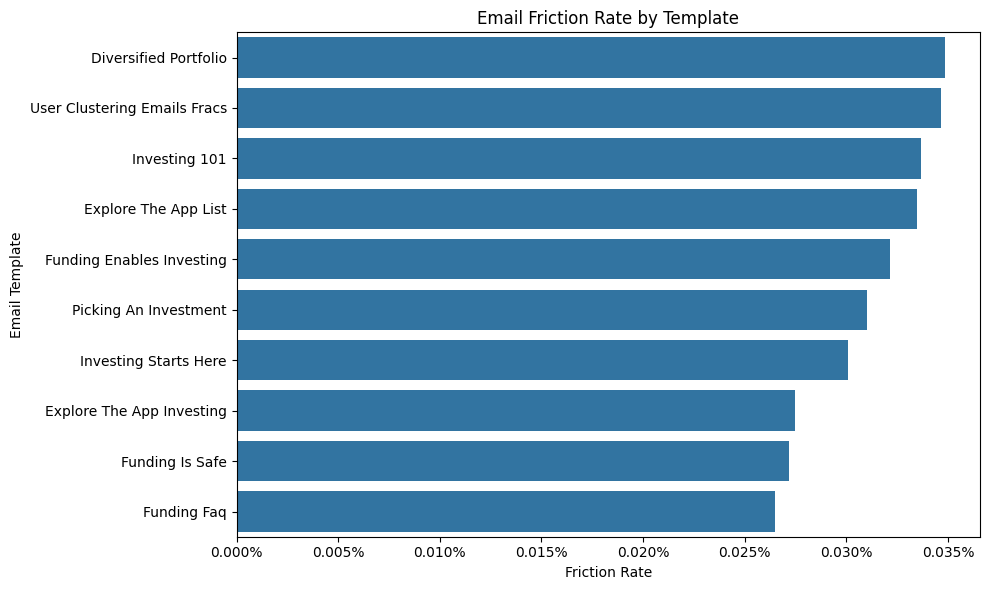

In [48]:
# Visualize friction rate by email template

plt.figure(figsize=(10, 6))

sns.barplot(
    data=friction_df,
    x='friction_rate',
    y='email_label'
)

plt.xlabel('Friction Rate')
plt.ylabel('Email Template')
plt.title('Email Friction Rate by Template')

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.3%}')
)

plt.tight_layout()
plt.show()

#### Key Finding

Overall email friction was very low. The unsubscribe rate was **0.026%**, the spam-report rate was **0.005%**, and the combined friction rate was only **0.031%**.

Friction rates were also consistently low across all 10 email templates, ranging from approximately **0.027% to 0.035%**. **Diversified Portfolio** had the highest observed friction rate at **0.035%**, while **Funding FAQ**, the template with the highest open rate, was among the lowest at **0.027%**.

Overall, there is no indication of substantial negative engagement from the email campaign based on unsubscribe and spam-report behavior.

## 2. Link & Funding Rate Analysis

Email engagement is useful only if it contributes to meaningful downstream user actions. This section examines whether users in the treatment sample linked a bank account or funded their account after the experiment began.

### 2.1 Treatment Group Outcomes

The experiment began on **November 30, 2020**. To distinguish experiment-period conversions from actions that occurred before the campaign, a user is counted as newly linked or funded only if the corresponding first-event timestamp occurred on or after the experiment start date.

Treatment outcomes are compared across the 24 experimental groups, which represent 12 behavioral segments under either a daily (`D`) or twice-weekly (`W`) email schedule.

In [49]:
# Define experiment start date

experiment_start = pd.Timestamp('2020-11-30')

# Create experiment-period conversion indicators

analysis_df['linked_during_experiment'] = (
    analysis_df['first_linked_bank_account_at'] >= experiment_start
).astype(int)

analysis_df['funded_during_experiment'] = (
    analysis_df['first_funded_at'] >= experiment_start
).astype(int)

print(
    f"Users linked after experiment start: "
    f"{analysis_df['linked_during_experiment'].sum():,}"
)

print(
    f"Users funded after experiment start: "
    f"{analysis_df['funded_during_experiment'].sum():,}"
)

Users linked after experiment start: 6,630
Users funded after experiment start: 13,991


In [50]:
# Check the observed outcome date range

print(
    "Latest linking date:",
    analysis_df['first_linked_bank_account_at'].max()
)

print(
    "Latest funding date:",
    analysis_df['first_funded_at'].max()
)

Latest linking date: 2020-12-18 08:00:04.948000
Latest funding date: 2020-12-18 08:37:53.291000


In [51]:
# Calculate link and funding rates by treatment group

treatment_outcomes_df = (
    analysis_df
    .groupby('group_name')
    .agg(
        users=('user_uuid', 'count'),
        linked=('linked_during_experiment', 'sum'),
        funded=('funded_during_experiment', 'sum')
    )
    .reset_index()
)

treatment_outcomes_df['link_rate'] = (
    treatment_outcomes_df['linked']
    / treatment_outcomes_df['users']
)

treatment_outcomes_df['funding_rate'] = (
    treatment_outcomes_df['funded']
    / treatment_outcomes_df['users']
)

treatment_outcomes_df = treatment_outcomes_df.sort_values(
    'funding_rate',
    ascending=False
).reset_index(drop=True)

treatment_outcomes_df

,group_name,users,linked,funded,link_rate,funding_rate
0,6M_App-link-20D_Act-5D_Act_D,20000,0,1925,0.00000,0.09625
1,6M_App-link-20D_Act-5D_Act_W,20000,0,1887,0.00000,0.09435
2,6M_App-20D_Act-5D_Act_D,20000,1291,1132,0.06455,0.05660
3,6M_App-20D_Act-5D_Act_W,20000,1267,1104,0.06335,0.05520
4,6M_App-link-20D_Act_D,20000,0,777,0.00000,0.03885
5,link-20D_Act-5D_Act_D,20000,0,731,0.00000,0.03655
6,6M_App-link-20D_Act_W,20000,0,722,0.00000,0.03610
7,link-20D_Act-5D_Act_W,20000,0,677,0.00000,0.03385
8,6M_App-20D_Act_D,20000,725,636,0.03625,0.03180
9,6M_App-20D_Act_W,20000,712,605,0.03560,0.03025


In [52]:
# Create a readable treatment outcome table

treatment_display_df = treatment_outcomes_df.copy()

treatment_display_df['link_rate'] = (
    treatment_display_df['link_rate'] * 100
).round(2)

treatment_display_df['funding_rate'] = (
    treatment_display_df['funding_rate'] * 100
).round(2)

treatment_display_df.columns = [
    'Treatment Group',
    'Users',
    'Linked',
    'Funded',
    'Link Rate (%)',
    'Funding Rate (%)'
]

treatment_display_df

,Treatment Group,Users,Linked,Funded,Link Rate (%),Funding Rate (%)
0,6M_App-link-20D_Act-5D_Act_D,20000,0,1925,0.00,9.62
1,6M_App-link-20D_Act-5D_Act_W,20000,0,1887,0.00,9.44
2,6M_App-20D_Act-5D_Act_D,20000,1291,1132,6.46,5.66
3,6M_App-20D_Act-5D_Act_W,20000,1267,1104,6.34,5.52
4,6M_App-link-20D_Act_D,20000,0,777,0.00,3.88
5,link-20D_Act-5D_Act_D,20000,0,731,0.00,3.66
6,6M_App-link-20D_Act_W,20000,0,722,0.00,3.61
7,link-20D_Act-5D_Act_W,20000,0,677,0.00,3.38
8,6M_App-20D_Act_D,20000,725,636,3.62,3.18
9,6M_App-20D_Act_W,20000,712,605,3.56,3.02


In [53]:
# Extract email delivery frequency from treatment group name

analysis_df['frequency'] = np.where(
    analysis_df['group_name'].str.endswith('_D'),
    'Daily',
    'Twice Weekly'
)

frequency_outcomes_df = (
    analysis_df
    .groupby('frequency')
    .agg(
        users=('user_uuid', 'count'),
        linked=('linked_during_experiment', 'sum'),
        funded=('funded_during_experiment', 'sum')
    )
    .reset_index()
)

frequency_outcomes_df['link_rate'] = (
    frequency_outcomes_df['linked']
    / frequency_outcomes_df['users']
)

frequency_outcomes_df['funding_rate'] = (
    frequency_outcomes_df['funded']
    / frequency_outcomes_df['users']
)

frequency_outcomes_df

,frequency,users,linked,funded,link_rate,funding_rate
0,Daily,240000,3399,7130,0.014162,0.029708
1,Twice Weekly,239999,3231,6861,0.013463,0.028588


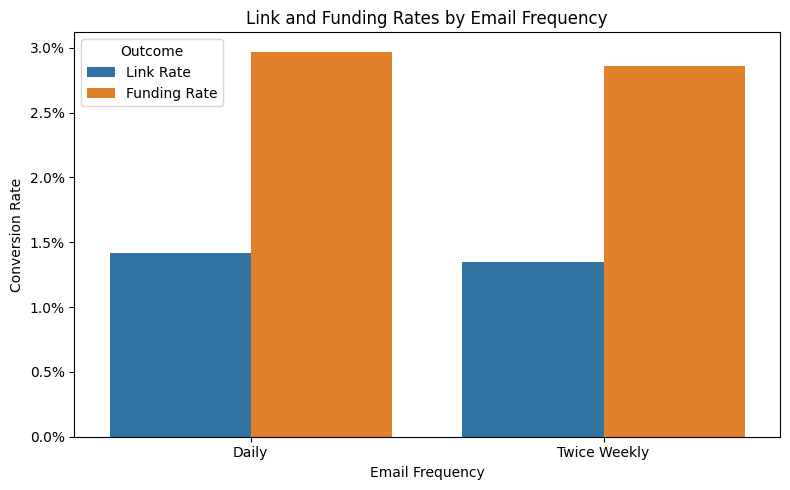

In [54]:
frequency_plot_df = frequency_outcomes_df.melt(
    id_vars='frequency',
    value_vars=['link_rate', 'funding_rate'],
    var_name='Outcome',
    value_name='Rate'
)

frequency_plot_df['Outcome'] = frequency_plot_df['Outcome'].map({
    'link_rate': 'Link Rate',
    'funding_rate': 'Funding Rate'
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=frequency_plot_df,
    x='frequency',
    y='Rate',
    hue='Outcome'
)

plt.xlabel('Email Frequency')
plt.ylabel('Conversion Rate')
plt.title('Link and Funding Rates by Email Frequency')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.1%}')
)

plt.tight_layout()
plt.show()

#### Key Findings

Treatment-group outcomes varied substantially across user segments. The `6M_App-link-20D_Act-5D_Act` segment had the highest observed funding rates, reaching **9.62%** under daily delivery and **9.44%** under twice-weekly delivery. Among users who were not already linked, `6M_App-20D_Act-5D_Act` had the highest observed link rates at **6.46%** and **6.34%**, respectively.

Across the full treatment sample, daily-email groups had an observed funding rate of **2.97%**, compared with **2.86%** for twice-weekly groups. Observed link rates were **1.42%** and **1.35%**, respectively. These differences are descriptive and should not yet be interpreted as evidence that daily delivery is more effective.

The available outcome data ends on **December 18, 2020**. Because the twice-weekly campaign extends beyond this date, these results represent **interim rather than final experiment outcomes**.

## 3. A/B Testing

Observed funding rates can differ across user segments because users have different baseline propensities to fund their accounts. To estimate whether the email campaign generated incremental impact, treatment outcomes are compared with corresponding no-email control groups that were constructed using the same segmentation rules.

### 3.1 Treatment vs Control

This section compares the observed funding rate of each treatment group with its corresponding control-group funding rate. The difference between the two rates represents the observed funding-rate lift associated with the email treatment.

In [55]:
# Inspect control-group structure

control_display_df = fund_control_df.copy()

control_display_df['funding_rate_in_control'] = (
    control_display_df['funding_rate_in_control'] * 100
).round(2)

control_display_df['link_rate_in_control'] = (
    control_display_df['link_rate_in_control'] * 100
).round(2)

control_display_df

,group_name,num_users_in_control,num_funded_in_control,funding_rate_in_control,num_link_in_control,link_rate_in_control
0,20D_Act-5D_Act_D,369786,7802,2.11,9899,2.68
1,20D_Act_D,274921,4053,1.47,5143,1.87
2,6M_App-20D_Act-5D_Act_D,193445,11556,5.97,13396,6.92
3,6M_App-20D_Act_D,178938,5636,3.15,6570,3.67
4,6M_App-link-20D_Act-5D_Act_D,29697,3047,10.26,29697,100.00
5,6M_App-link-20D_Act_D,7883,291,3.69,7883,100.00
6,6M_App-link_D,87008,1072,1.23,87008,100.00
7,6M_App_D,774827,8675,1.12,10086,1.30
8,ML_unfund_exp_control_D,1000000,4443,0.44,5461,0.55
9,link-20D_Act-5D_Act_D,96513,3645,3.78,96513,100.00


In [56]:
print(f"Number of control groups: {len(fund_control_df)}")

print("\nControl group names:")
for group in fund_control_df['group_name']:
    print(group)

Number of control groups: 12

Control group names:
20D_Act-5D_Act_D
20D_Act_D
6M_App-20D_Act-5D_Act_D
6M_App-20D_Act_D
6M_App-link-20D_Act-5D_Act_D
6M_App-link-20D_Act_D
6M_App-link_D
6M_App_D
ML_unfund_exp_control_D
link-20D_Act-5D_Act_D
link-20D_Act_D
link_D


In [57]:
# Create base segment names for treatment and control groups

treatment_outcomes_df['base_group_name'] = (
    treatment_outcomes_df['group_name']
    .str.replace(r'_[DW]$', '', regex=True)
)

control_df = fund_control_df.copy()

control_df['base_group_name'] = (
    control_df['group_name']
    .str.replace(r'_[DW]$', '', regex=True)
)

control_df[
    [
        'group_name',
        'base_group_name',
        'num_users_in_control',
        'num_funded_in_control',
        'funding_rate_in_control'
    ]
]

,group_name,base_group_name,num_users_in_control,num_funded_in_control,funding_rate_in_control
0,20D_Act-5D_Act_D,20D_Act-5D_Act,369786,7802,0.021099
1,20D_Act_D,20D_Act,274921,4053,0.014742
2,6M_App-20D_Act-5D_Act_D,6M_App-20D_Act-5D_Act,193445,11556,0.059738
3,6M_App-20D_Act_D,6M_App-20D_Act,178938,5636,0.031497
4,6M_App-link-20D_Act-5D_Act_D,6M_App-link-20D_Act-5D_Act,29697,3047,0.102603
5,6M_App-link-20D_Act_D,6M_App-link-20D_Act,7883,291,0.036915
6,6M_App-link_D,6M_App-link,87008,1072,0.012321
7,6M_App_D,6M_App,774827,8675,0.011196
8,ML_unfund_exp_control_D,ML_unfund_exp_control,1000000,4443,0.004443
9,link-20D_Act-5D_Act_D,link-20D_Act-5D_Act,96513,3645,0.037767


In [58]:
# Match each treatment group to its corresponding control segment

ab_comparison_df = treatment_outcomes_df.merge(
    control_df[
        [
            'base_group_name',
            'num_users_in_control',
            'num_funded_in_control',
            'funding_rate_in_control'
        ]
    ],
    on='base_group_name',
    how='left',
    validate='many_to_one'
)

print(
    "Treatment groups without matched control:",
    ab_comparison_df['funding_rate_in_control'].isna().sum()
)

Treatment groups without matched control: 0


In [59]:
# Calculate funding-rate lift relative to control

ab_comparison_df['funding_lift_pp'] = (
    ab_comparison_df['funding_rate']
    - ab_comparison_df['funding_rate_in_control']
) * 100

ab_comparison_df['relative_lift'] = (
    (
        ab_comparison_df['funding_rate']
        / ab_comparison_df['funding_rate_in_control']
    ) - 1
) * 100

ab_comparison_df = ab_comparison_df.sort_values(
    'funding_lift_pp',
    ascending=False
).reset_index(drop=True)

In [60]:
ab_display_df = ab_comparison_df[
    [
        'group_name',
        'funding_rate',
        'funding_rate_in_control',
        'funding_lift_pp',
        'relative_lift'
    ]
].copy()

ab_display_df['funding_rate'] = (
    ab_display_df['funding_rate'] * 100
).round(2)

ab_display_df['funding_rate_in_control'] = (
    ab_display_df['funding_rate_in_control'] * 100
).round(2)

ab_display_df['funding_lift_pp'] = (
    ab_display_df['funding_lift_pp'].round(2)
)

ab_display_df['relative_lift'] = (
    ab_display_df['relative_lift'].round(1)
)

ab_display_df.columns = [
    'Treatment Group',
    'Treatment Funding Rate (%)',
    'Control Funding Rate (%)',
    'Lift (pp)',
    'Relative Lift (%)'
]

ab_display_df

,Treatment Group,Treatment Funding Rate (%),Control Funding Rate (%),Lift (pp),Relative Lift (%)
0,20D_Act_D,1.70,1.47,0.23,15.3
1,6M_App-link-20D_Act_D,3.88,3.69,0.19,5.2
2,link-20D_Act_W,2.36,2.22,0.13,6.0
3,ML_unfund_exp_control_D,0.55,0.44,0.11,23.8
4,link_D,0.71,0.64,0.07,11.2
5,6M_App_D,1.17,1.12,0.05,4.5
6,link_W,0.68,0.64,0.04,5.7
7,6M_App-20D_Act_D,3.18,3.15,0.03,1.0
8,6M_App_W,1.14,1.12,0.03,2.3
9,20D_Act_W,1.47,1.47,-0.00,-0.3


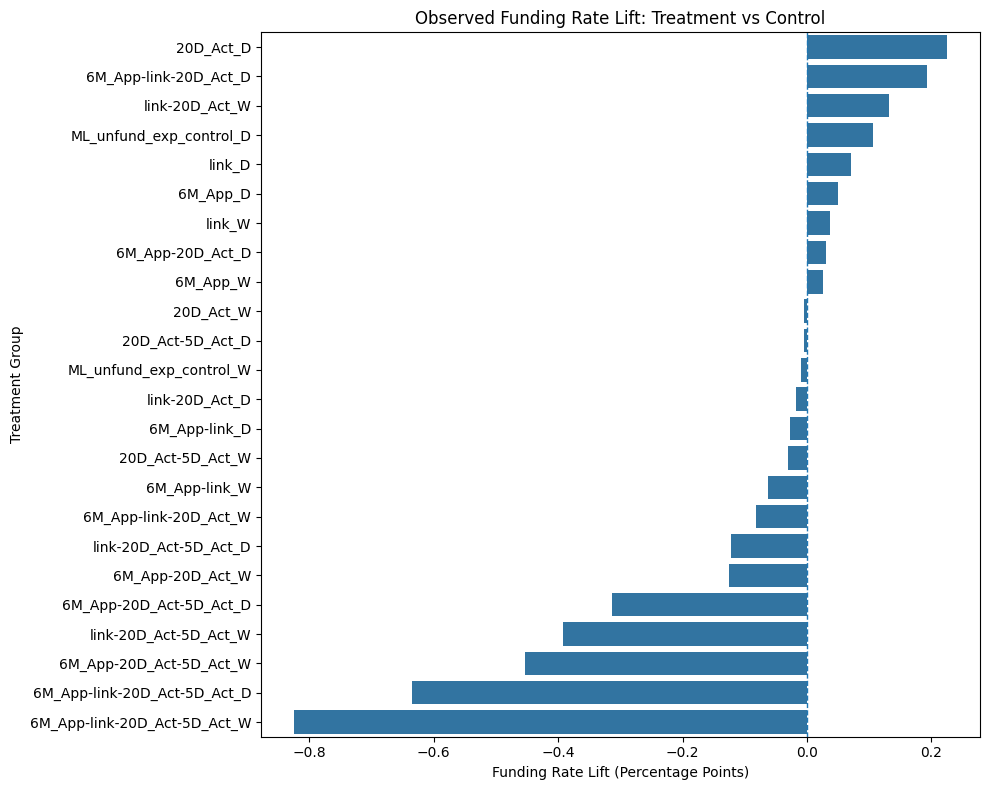

In [61]:
# Visualize absolute funding-rate lift relative to control

plt.figure(figsize=(10, 8))

sns.barplot(
    data=ab_comparison_df,
    x='funding_lift_pp',
    y='group_name'
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Funding Rate Lift (Percentage Points)')
plt.ylabel('Treatment Group')
plt.title('Observed Funding Rate Lift: Treatment vs Control')

plt.tight_layout()
plt.show()

#### Key Findings

The observed effect of the email treatment varied across user segments rather than showing a consistent positive lift. Of the 24 treatment-frequency groups, some had higher funding rates than their corresponding controls, while others had similar or lower rates.

The largest positive observed lift occurred for `20D_Act_D`, where the funding rate increased from **1.47% in the control group to 1.70% in treatment**, a difference of **+0.23 percentage points**. Positive lifts were also observed for several other groups, although most were relatively small.

In contrast, several high-baseline-conversion segments had lower treatment funding rates than their controls. The largest negative difference occurred for `6M_App-link-20D_Act-5D_Act_W`, with a **9.44%** treatment funding rate compared with **10.26%** in control, a difference of **−0.83 percentage points**.

Overall, the descriptive results suggest that the email campaign's relationship with funding outcomes may differ across user segments. Statistical testing is needed to determine which observed differences are unlikely to be explained by sampling variation.

> **Note:** Treatment outcomes are observed only through December 18, 2020. Because the twice-weekly campaign had not yet completed by this date, treatment-control comparisons involving twice-weekly groups should be interpreted as interim results.

### 3.2 Proportion Z-Test

The descriptive comparison shows that treatment funding rates were higher than control rates for some user segments and lower for others. To determine whether the observed positive differences provide statistical evidence of an improvement, a two-proportion z-test is performed for each treatment-control pair.

For each group, the hypotheses are:

- **Null hypothesis (H₀):** The treatment funding rate is less than or equal to the control funding rate.
- **Alternative hypothesis (H₁):** The treatment funding rate is greater than the control funding rate.

A significance level of **α = 0.05** is used. A p-value below 0.05 indicates evidence that the email treatment produced a higher funding rate than the corresponding control group.

In [62]:
# Run one-sided two-proportion z-tests for treatment vs control

z_test_results = []

for _, row in ab_comparison_df.iterrows():

    count = np.array([
        row['funded'],
        row['num_funded_in_control']
    ])

    nobs = np.array([
        row['users'],
        row['num_users_in_control']
    ])

    z_stat, p_value = proportions_ztest(
        count,
        nobs,
        alternative='larger'
    )

    z_test_results.append({
        'group_name': row['group_name'],
        'treatment_rate': row['funding_rate'],
        'control_rate': row['funding_rate_in_control'],
        'lift_pp': row['funding_lift_pp'],
        'z_stat': z_stat,
        'p_value': p_value,
        'significant_positive_lift': p_value < 0.05
    })

z_test_df = pd.DataFrame(z_test_results)

z_test_df = z_test_df.sort_values(
    'p_value'
).reset_index(drop=True)

z_test_df

,group_name,treatment_rate,control_rate,lift_pp,z_stat,p_value,significant_positive_lift
0,20D_Act_D,0.01700,0.014742,0.225758,2.544726,0.005468,True
1,ML_unfund_exp_control_D,0.00550,0.004443,0.105700,2.220305,0.013199,True
2,link_D,0.00710,0.006386,0.071396,1.252205,0.105248,False
3,link-20D_Act_W,0.02355,0.022225,0.132458,1.098384,0.136018,False
4,6M_App-link-20D_Act_D,0.03885,0.036915,0.193512,0.758165,0.224176,False
5,6M_App_D,0.01170,0.011196,0.050395,0.668406,0.251937,False
6,link_W,0.00675,0.006386,0.036430,0.639297,0.261315,False
7,6M_App_W,0.01145,0.011196,0.025395,0.336917,0.368090,False
8,6M_App-20D_Act_D,0.03180,0.031497,0.030306,0.232618,0.408029,False
9,20D_Act-5D_Act_D,0.02105,0.021099,-0.004869,-0.046670,0.518612,False


In [63]:
# Create a readable statistical test summary

z_test_display_df = z_test_df.copy()

z_test_display_df['treatment_rate'] = (
    z_test_display_df['treatment_rate'] * 100
).round(2)

z_test_display_df['control_rate'] = (
    z_test_display_df['control_rate'] * 100
).round(2)

z_test_display_df['lift_pp'] = (
    z_test_display_df['lift_pp'].round(2)
)

z_test_display_df['z_stat'] = (
    z_test_display_df['z_stat'].round(2)
)

z_test_display_df['p_value'] = (
    z_test_display_df['p_value'].round(4)
)

z_test_display_df.columns = [
    'Treatment Group',
    'Treatment Rate (%)',
    'Control Rate (%)',
    'Lift (pp)',
    'Z-Statistic',
    'P-Value',
    'Significant Positive Lift'
]

z_test_display_df

,Treatment Group,Treatment Rate (%),Control Rate (%),Lift (pp),Z-Statistic,P-Value,Significant Positive Lift
0,20D_Act_D,1.70,1.47,0.23,2.54,0.0055,True
1,ML_unfund_exp_control_D,0.55,0.44,0.11,2.22,0.0132,True
2,link_D,0.71,0.64,0.07,1.25,0.1052,False
3,link-20D_Act_W,2.36,2.22,0.13,1.10,0.1360,False
4,6M_App-link-20D_Act_D,3.88,3.69,0.19,0.76,0.2242,False
5,6M_App_D,1.17,1.12,0.05,0.67,0.2519,False
6,link_W,0.68,0.64,0.04,0.64,0.2613,False
7,6M_App_W,1.14,1.12,0.03,0.34,0.3681,False
8,6M_App-20D_Act_D,3.18,3.15,0.03,0.23,0.4080,False
9,20D_Act-5D_Act_D,2.10,2.11,-0.00,-0.05,0.5186,False


In [64]:
# Identify treatment groups with statistically significant positive lift

significant_groups = z_test_df[
    z_test_df['significant_positive_lift']
].copy()

print(
    f"Groups with significant positive funding lift: "
    f"{len(significant_groups)} out of {len(z_test_df)}"
)

display(
    significant_groups[
        [
            'group_name',
            'treatment_rate',
            'control_rate',
            'lift_pp',
            'p_value'
        ]
    ]
)

Groups with significant positive funding lift: 2 out of 24


,group_name,treatment_rate,control_rate,lift_pp,p_value
0,20D_Act_D,0.0170,0.014742,0.225758,0.005468
1,ML_unfund_exp_control_D,0.0055,0.004443,0.105700,0.013199


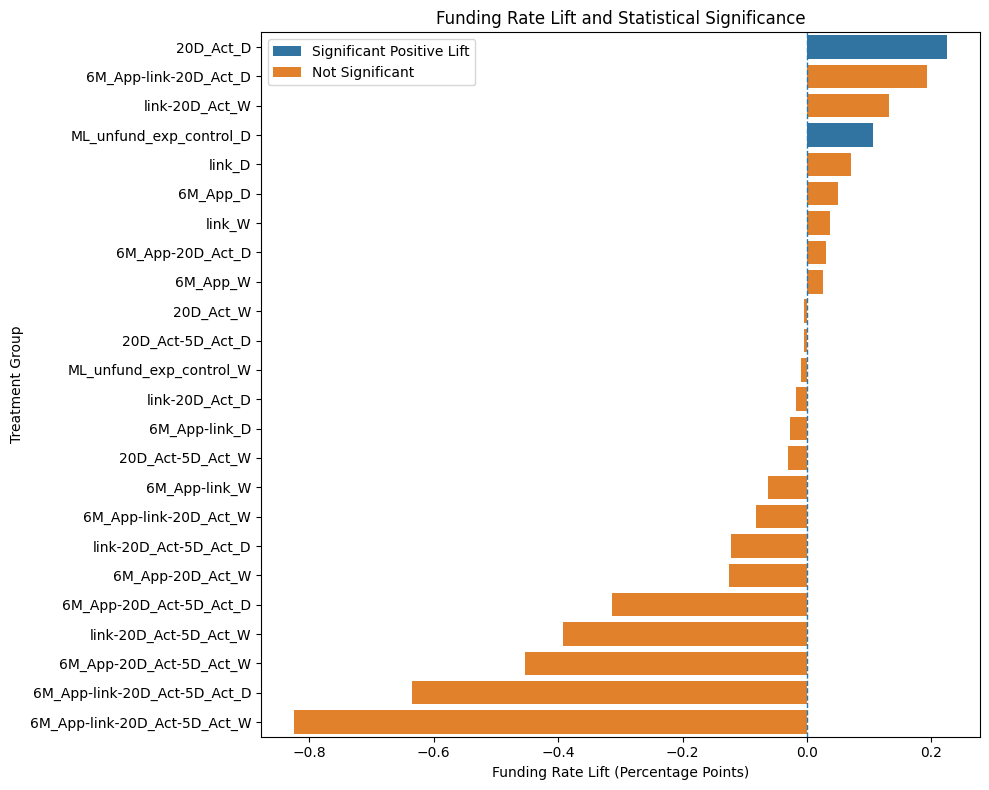

In [65]:
# Prepare significance labels for visualization

z_test_plot_df = z_test_df.sort_values(
    'lift_pp',
    ascending=False
).copy()

z_test_plot_df['Statistical Result'] = np.where(
    z_test_plot_df['significant_positive_lift'],
    'Significant Positive Lift',
    'Not Significant'
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=z_test_plot_df,
    x='lift_pp',
    y='group_name',
    hue='Statistical Result',
    dodge=False
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Funding Rate Lift (Percentage Points)')
plt.ylabel('Treatment Group')
plt.title('Funding Rate Lift and Statistical Significance')

plt.legend(title='')
plt.tight_layout()
plt.show()

#### Key Findings

At the **5% significance level**, only **2 of the 24 treatment-frequency groups** showed statistically significant evidence of a higher funding rate than their corresponding control groups.

The strongest result was observed for `20D_Act_D`, where funding increased from **1.47% in control to 1.70% in treatment**, a lift of **+0.23 percentage points** (*p* = **0.0055**). `ML_unfund_exp_control_D` also showed a significant positive lift, increasing from **0.44% to 0.55%**, or **+0.11 percentage points** (*p* = **0.0132**).

The remaining 22 groups did not show statistically significant positive funding lift under the one-sided test. Overall, the results do not support a broad increase in funding across all user segments; instead, the observed positive effect appears concentrated in specific treatment groups.

Because 24 segment-level tests were conducted and the experiment data is incomplete for the twice-weekly schedule, these results should be interpreted as preliminary evidence rather than definitive conclusions.

## 4. Time Series Analysis

Email engagement may change over the course of a campaign as users receive repeated messages. This section examines how open rates evolve over time and whether the available data covers the full planned experiment period.

### 4.1 Open Rate by Scheduled Send Day

The experiment used two delivery schedules. Daily groups received emails on Days 0-9, while twice-weekly groups received emails on Days 0, 4, 7, 11, 14, 18, 21, 25, 28, and 32.

Because users may open an email several days after receiving it, comparing opens and deliveries occurring on the same calendar day can misrepresent open rates. Instead, each user's randomized email order is mapped to the scheduled send day, and the final engagement status of that email is used to calculate open rate.

This allows engagement to be compared across successive email sends and directly tests whether the first email sent on Day 0 consistently receives the highest open rate.

In [70]:
# Define scheduled send days for each delivery frequency

daily_schedule = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

weekly_schedule = [0, 4, 7, 11, 14, 18, 21, 25, 28, 32]

In [71]:
# Reshape randomized email orders to one row per user-email send

order_cols = [f'order_{i}' for i in range(10)]

email_order_long = analysis_df[
    ['user_uuid', 'frequency'] + order_cols
].melt(
    id_vars=['user_uuid', 'frequency'],
    value_vars=order_cols,
    var_name='send_number',
    value_name='email_id'
)

email_order_long['send_number'] = (
    email_order_long['send_number']
    .str.extract(r'(\d+)')
    .astype(int)
)

email_order_long.head()

,user_uuid,frequency,send_number,email_id
0,id_2623238174270264636,Daily,0,5
1,id_14752263936159847779,Daily,0,3
2,id_3723259155072282145,Daily,0,8
3,id_9433964625840258739,Daily,0,1
4,id_17251718038176858460,Daily,0,6


In [72]:
# Map randomized email IDs to email template names

email_id_map = dict(enumerate(PO_number_list))

email_order_long['email'] = (
    email_order_long['email_id']
    .map(email_id_map)
)

In [73]:
# Map each send number to its scheduled experiment day

email_order_long['scheduled_day'] = np.where(
    email_order_long['frequency'] == 'Daily',
    email_order_long['send_number'],
    email_order_long['send_number'].map(
        dict(enumerate(weekly_schedule))
    )
)

email_order_long.head()

,user_uuid,frequency,send_number,email_id,email,scheduled_day
0,id_2623238174270264636,Daily,0,5,ml_funding_is_safe,0
1,id_14752263936159847779,Daily,0,3,ml_funding_faq,0
2,id_3723259155072282145,Daily,0,8,ml_diversified_portfolio,0
3,id_9433964625840258739,Daily,0,1,ml_investing_starts_here,0
4,id_17251718038176858460,Daily,0,6,ml_picking_an_investment,0


In [74]:
# Reshape user-level email engagement status

email_status_long = analysis_df[
    ['user_uuid'] + email_cols
].melt(
    id_vars='user_uuid',
    value_vars=email_cols,
    var_name='email',
    value_name='status'
)

send_status_df = email_order_long.merge(
    email_status_long,
    on=['user_uuid', 'email'],
    how='left',
    validate='one_to_one'
)

send_status_df.head()

,user_uuid,frequency,send_number,email_id,email,scheduled_day,status
0,id_2623238174270264636,Daily,0,5,ml_funding_is_safe,0,NaN
1,id_14752263936159847779,Daily,0,3,ml_funding_faq,0,delivered
2,id_3723259155072282145,Daily,0,8,ml_diversified_portfolio,0,delivered
3,id_9433964625840258739,Daily,0,1,ml_investing_starts_here,0,delivered
4,id_17251718038176858460,Daily,0,6,ml_picking_an_investment,0,NaN


In [75]:
# Keep emails with a recorded delivery outcome

send_status_df['opened'] = (
    send_status_df['status'] == 'open'
)

send_status_df['received'] = (
    send_status_df['status']
    .isin(['open', 'delivered', 'unsubscribe', 'spamreport'])
)

scheduled_open_rate_df = (
    send_status_df[
        send_status_df['received']
    ]
    .groupby(
        ['frequency', 'scheduled_day']
    )
    .agg(
        received_emails=('received', 'sum'),
        opened_emails=('opened', 'sum')
    )
    .reset_index()
)

scheduled_open_rate_df['open_rate'] = (
    scheduled_open_rate_df['opened_emails']
    / scheduled_open_rate_df['received_emails']
)

scheduled_open_rate_df

,frequency,scheduled_day,received_emails,opened_emails,open_rate
0,Daily,0,228056,42595,0.186774
1,Daily,1,227059,44454,0.195782
2,Daily,2,226240,43842,0.193785
3,Daily,3,225578,41976,0.186082
4,Daily,4,224674,42295,0.188251
5,Daily,5,217342,40193,0.184930
6,Daily,6,216854,36057,0.166273
7,Daily,7,216460,39898,0.184320
8,Daily,8,215882,39334,0.182201
9,Daily,9,215451,40219,0.186674


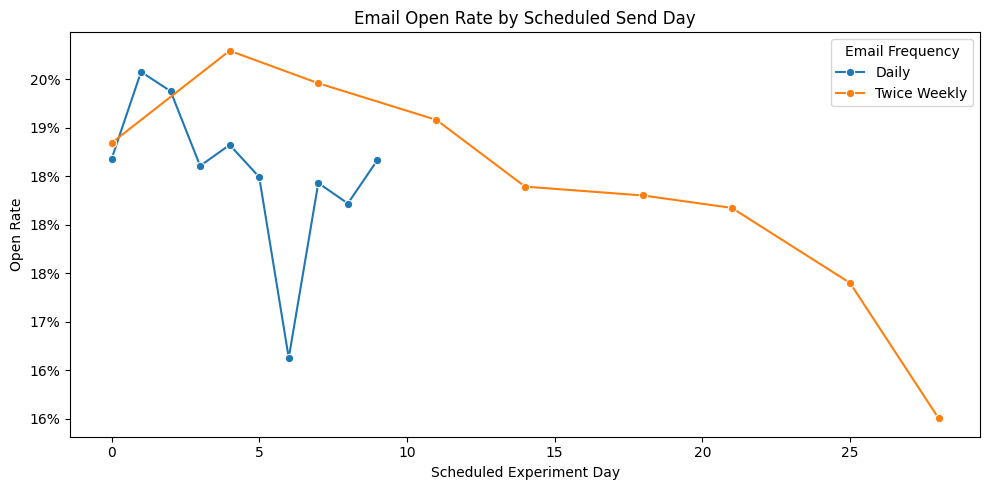

In [80]:
# Exclude incomplete scheduled days from the visualization

plot_open_rate_df = scheduled_open_rate_df[
    scheduled_open_rate_df['received_emails'] >= 1000
].copy()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=plot_open_rate_df,
    x='scheduled_day',
    y='open_rate',
    hue='frequency',
    marker='o'
)

plt.xlabel('Scheduled Experiment Day')
plt.ylabel('Open Rate')
plt.title('Email Open Rate by Scheduled Send Day')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)

plt.legend(title='Email Frequency')
plt.tight_layout()
plt.show()

In [83]:
# Compare Day 0 with the highest observed open rate for each schedule

for frequency in ['Daily', 'Twice Weekly']:

    subset = plot_open_rate_df[
        plot_open_rate_df['frequency'] == frequency
    ]

    highest = subset.loc[
        subset['open_rate'].idxmax()
    ]

    day_0 = subset.loc[
        subset['scheduled_day'] == 0,
        'open_rate'
    ].iloc[0]

    print(f"{frequency}:")
    print(f"  Day 0 open rate: {day_0:.2%}")
    print(
        f"  Highest open rate: "
        f"Day {int(highest['scheduled_day'])} "
        f"({highest['open_rate']:.2%})"
    )
    print()

Daily:
  Day 0 open rate: 18.68%
  Highest open rate: Day 1 (19.58%)

Twice Weekly:
  Day 0 open rate: 18.84%
  Highest open rate: Day 4 (19.80%)



#### Key Findings

Day 0 did not have the highest observed open rate under either delivery schedule. For the daily groups, the open rate increased from **18.68% on Day 0 to a peak of 19.58% on Day 1**. For the twice-weekly groups, it increased from **18.84% on Day 0 to a peak of 19.80% on Day 4**.

Open rates remained relatively stable during the earlier sends but generally weakened later in the campaign, particularly for the twice-weekly schedule, which declined to **16.00% by Day 28**. This pattern suggests that engagement may decrease as the campaign progresses and that later sends may provide diminishing engagement.

Day 32 is excluded from the trend interpretation because only one email had a recorded delivery outcome, indicating that the available data does not fully cover the final scheduled send.

### 4.2 Has the Experiment Finished?

The twice-weekly schedule was designed to continue through **Day 32**, followed by at least **two additional weeks of observation** after the final email. To determine whether the experiment has been fully observed, the latest available data is compared with the planned experiment timeline.

In [84]:
# Define the planned experiment timeline

last_scheduled_day = 32
follow_up_days = 14

last_email_date = (
    experiment_start
    + pd.Timedelta(days=last_scheduled_day)
)

minimum_observation_end = (
    last_email_date
    + pd.Timedelta(days=follow_up_days)
)

# Find the latest available dates in the email and user outcome data

latest_email_event = (
    email_event_summary_df[
        'stitch_email_events.dt_date'
    ].max()
)

latest_user_outcome = max(
    user_event_df['first_funded_at'].max(),
    user_event_df['first_linked_bank_account_at'].max()
)

latest_available_date = max(
    latest_email_event,
    latest_user_outcome
)

print(f"Experiment start: {experiment_start.date()}")
print(f"Last scheduled email: {last_email_date.date()}")
print(f"Minimum observation end: {minimum_observation_end.date()}")
print(f"Latest email event: {latest_email_event.date()}")
print(f"Latest user outcome: {latest_user_outcome.date()}")
print(f"Latest available date: {latest_available_date.date()}")

Experiment start: 2020-11-30
Last scheduled email: 2021-01-01
Minimum observation end: 2021-01-15
Latest email event: 2020-12-30
Latest user outcome: 2020-12-18
Latest available date: 2020-12-30


In [85]:
# Check whether the full planned observation period is available

experiment_complete = (
    latest_available_date >= minimum_observation_end
)

print(f"Full observation period available: {experiment_complete}")

if not experiment_complete:
    days_missing = (
        minimum_observation_end
        - latest_available_date
    ).days

    print(
        f"Additional observation needed: approximately {days_missing} days"
    )

Full observation period available: False
Additional observation needed: approximately 16 days


#### Key Finding

The experiment has **not been fully observed**. The final twice-weekly email was scheduled for **January 1, 2021**, and the experiment design requires at least two additional weeks of observation, extending the minimum observation period through **January 15, 2021**.

However, the latest available email event is from **December 30, 2020**, while the latest recorded linking or funding outcome is from **December 18, 2020**. The available data therefore falls approximately **16 days short** of the planned observation window.

As a result, the treatment, conversion, and A/B testing results in this analysis should be interpreted as **interim results rather than final experiment outcomes**, particularly for the twice-weekly groups whose email sequence was not fully observed.

## 5. Funnel Analysis

Unlike the treatment-level outcome analysis, this funnel applies sequential conditions at each stage, so the counts represent users progressing through the full observed path rather than all users who linked or funded after the experiment began.

As an optional extension, a simple conversion funnel is used to examine how users progress from **email engagement → account linking → account funding**.

To avoid counting users who had already linked their accounts before the experiment, the funnel is restricted to users who were **not linked at baseline**. Linking and funding are counted only when the corresponding event occurred on or after the experiment start date.

Because the available outcome data does not cover the full planned experiment period, this funnel represents observed conversions to date rather than final campaign conversion.

In [86]:
# Restrict the funnel to users who were not linked at baseline

funnel_df = analysis_df[
    analysis_df['link_flag'] == False
].copy()

# Identify whether each user opened at least one email

funnel_df['opened_email'] = (
    funnel_df[email_cols]
    .eq('open')
    .any(axis=1)
)

# Identify post-experiment linking and funding outcomes

funnel_df['linked_after_start'] = (
    funnel_df['first_linked_bank_account_at'].notna()
    & (funnel_df['first_linked_bank_account_at'] >= experiment_start)
)

funnel_df['funded_after_start'] = (
    funnel_df['first_funded_at'].notna()
    & (funnel_df['first_funded_at'] >= experiment_start)
)

print(f"Eligible users: {len(funnel_df):,}")
print(f"Opened at least one email: {funnel_df['opened_email'].sum():,}")
print(f"Linked after experiment start: {funnel_df['linked_after_start'].sum():,}")
print(f"Funded after experiment start: {funnel_df['funded_after_start'].sum():,}")

Eligible users: 240,000
Opened at least one email: 118,983
Linked after experiment start: 6,630
Funded after experiment start: 5,608


In [87]:
# Construct sequential funnel stages

total_users = len(funnel_df)

opened_users = (
    funnel_df['opened_email']
).sum()

opened_and_linked = (
    funnel_df['opened_email']
    & funnel_df['linked_after_start']
).sum()

opened_linked_and_funded = (
    funnel_df['opened_email']
    & funnel_df['linked_after_start']
    & funnel_df['funded_after_start']
).sum()

funnel_summary_df = pd.DataFrame({
    'stage': [
        'Eligible Users',
        'Opened Email',
        'Linked Account',
        'Funded Account'
    ],
    'users': [
        total_users,
        opened_users,
        opened_and_linked,
        opened_linked_and_funded
    ]
})

funnel_summary_df['% of Eligible Users'] = (
    funnel_summary_df['users']
    / total_users
    * 100
).round(2)

funnel_summary_df

,stage,users,% of Eligible Users
0,Eligible Users,240000,100.00
1,Opened Email,118983,49.58
2,Linked Account,4662,1.94
3,Funded Account,3892,1.62


In [88]:
# Calculate conversion between consecutive funnel stages

funnel_summary_df['Stage Conversion (%)'] = (
    funnel_summary_df['users']
    / funnel_summary_df['users'].shift(1)
    * 100
).round(2)

funnel_summary_df.loc[
    0, 'Stage Conversion (%)'
] = 100.0

funnel_summary_df

,stage,users,% of Eligible Users,Stage Conversion (%)
0,Eligible Users,240000,100.00,100.00
1,Opened Email,118983,49.58,49.58
2,Linked Account,4662,1.94,3.92
3,Funded Account,3892,1.62,83.48


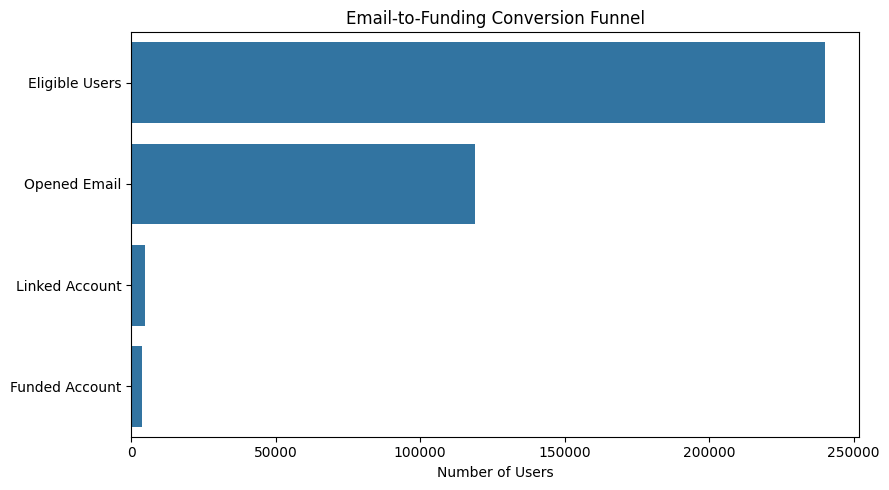

In [89]:
# Visualize the conversion funnel

plt.figure(figsize=(9, 5))

sns.barplot(
    data=funnel_summary_df,
    x='users',
    y='stage'
)

plt.xlabel('Number of Users')
plt.ylabel('')
plt.title('Email-to-Funding Conversion Funnel')

plt.tight_layout()
plt.show()

#### Key Findings

Among the **240,000 users who were not linked at baseline**, **49.58%** opened at least one campaign email. However, only **3.92% of users who opened an email subsequently linked an account**, making the **open-to-link transition the largest drop-off in the observed funnel**.

Among users who both opened an email and subsequently linked an account, **83.48% went on to fund their account**. Overall, **1.62% of eligible users** completed the full observed path from email open to account linking and funding.

This suggests that the main observed funnel bottleneck occurs between **email engagement and account linking**, rather than between linking and funding. However, the funnel is descriptive rather than causal, and the incomplete experiment window means these conversion rates should be interpreted as interim results.

## 6. Conclusions & Recommendations

### Key Conclusions

The experiment produced several actionable findings across email content, user segmentation, conversion, and campaign timing:

- **Email content matters.** `Funding FAQ` achieved the highest open rate at **25.99%**, substantially above the other templates, whose open rates were generally around 17–18%.

- **Recent user activity is associated with stronger engagement.** Users active within the previous 20 days had an open rate of **19.41%**, compared with **16.47%** among inactive users, the largest difference among the examined user characteristics.

- **Email treatment did not consistently increase funding across all segments.** Only **2 of 24 treatment-frequency groups** showed statistically significant positive funding lift at the 5% level. The strongest evidence was observed for `20D_Act_D`, with funding increasing from **1.47% to 1.70%** (+0.23 percentage points, *p* = 0.0055).

- **Day 0 was not the highest-engagement send.** Daily groups reached their highest observed open rate on **Day 1 (19.58%)**, while twice-weekly groups peaked on **Day 4 (19.80%)**. Engagement generally weakened during later sends, particularly in the twice-weekly campaign.

- **The main observed funnel bottleneck is between opening an email and linking an account.** Among eligible users, **49.58%** opened at least one email, but only **3.92% of openers** subsequently linked an account. In contrast, **83.48%** of users who opened and linked subsequently funded their account.

### Recommendations

1. **Prioritize high-performing content.** Use the strong performance of the `Funding FAQ` template as a starting point for future messaging tests and investigate which elements of the template drive higher engagement.

2. **Target and personalize by user activity.** Recent activity was strongly associated with email engagement, suggesting that behavioral signals can help identify more responsive audiences and support more targeted messaging strategies.

3. **Focus optimization on the open-to-link step.** Since the largest funnel drop-off occurs after users open an email but before they link an account, future experiments should test changes to calls-to-action, messaging, and the account-linking journey.

4. **Continue testing campaign timing and frequency.** Later sends showed weaker engagement, while the A/B test did not demonstrate broad funding lift across all segments. Future experiments should test shorter sequences or alternative send intervals rather than assuming that additional emails generate additional value.

### Limitation

The experiment is **not fully observed** in the available data. The final twice-weekly email was scheduled for January 1, 2021, with at least two additional weeks of follow-up required, while the latest available data ends before the planned observation window is complete. Therefore, conversion rates and treatment-control comparisons should be interpreted as **interim rather than final experiment results**.